<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re
from datetime import datetime

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [184]:
data = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep = ';')

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [185]:
display(data.head())

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

4. Обратите внимание на информацию о числе непустых значений.

In [186]:
display(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Пол, возраст                     44744 non-null  str  
 1   ЗП                               44744 non-null  str  
 2   Ищет работу на должность:        44744 non-null  str  
 3   Город, переезд, командировки     44744 non-null  str  
 4   Занятость                        44744 non-null  str  
 5   График                           44744 non-null  str  
 6   Опыт работы                      44576 non-null  str  
 7   Последнее/нынешнее место работы  44743 non-null  str  
 8   Последняя/нынешняя должность     44742 non-null  str  
 9   Образование и ВУЗ                44744 non-null  str  
 10  Обновление резюме                44744 non-null  str  
 11  Авто                             44744 non-null  str  
dtypes: str(12)
memory usage: 4.1 MB


None

5. Выведите основную статистическую информацию о столбцах.


In [187]:
display(data.describe())

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Московский технически...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [188]:
def type_education(df, source_col='Образование и ВУЗ', target_col='Образование'):
    
    text = (
        df[source_col]
        .fillna('')
        .astype(str)
        .str.split(' ')
        .str[:2]
        .str.join(' ')
    )
    
    replacements = {
        r'^Высшее образование.*': 'высшее',
        r'^Неоконченное высшее.*': 'неоконченное высшее',
        r'^Среднее специальное.*': 'среднее специальное',
        r'^Среднее образование.*': 'среднее'
    }
    
    result = text.replace(replacements, regex=True)
    result[df[source_col].isna()] = 'Не указано'
    return result


data['Образование'] = type_education(data)

data.drop('Образование и ВУЗ', axis = 'columns') #Временное удаление колонки, чтобы не мешалась при извлечении пола и возраста

data.head()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто,Образование
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано,высшее
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано,среднее специальное
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано,высшее
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано,высшее


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [189]:
data['Пол'] = data['Пол, возраст'].str.extract(r'(Мужчина|Женщина)')[0].map({
    'Мужчина': 'М', 'Женщина': 'Ж'
})

data['Возраст'] = pd.to_numeric(
    data['Пол, возраст'].str.extract(r'(\d+)')[0],
    errors='coerce', downcast='integer'
)

data.drop('Пол, возраст', axis='columns')

,ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто,Образование,Пол,Возраст
0,29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39
1,40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано,высшее,М,60
2,20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано,среднее специальное,Ж,36
3,100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано,высшее,М,38
4,140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано,высшее,Ж,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44739,50000 руб.,"Финансист, аналитик, экономист, бухгалтер, мен...","Тверь , готов к переезду (Москва, Химки) , гот...",полная занятость,"полный день, удаленная работа","Опыт работы 7 лет 7 месяцев Финансист, аналит...","ООО ""IAS"" (независимый участник объединения Ru...",Руководитель субгруппы,Высшее образование 2015 Московский гуманитарн...,22.04.2019 12:32,Не указано,высшее,М,30
44740,39000 руб.,"Системный администратор, IT-специалист","Липецк , готов к переезду , готов к командировкам","проектная работа, частичная занятость, полная ...","удаленная работа, гибкий график, полный день, ...","Опыт работы 7 лет Системный администратор, IT...",ИП Пестрецов,Предприниматель,Высшее образование (Бакалавр) 2016 Воронежски...,22.04.2019 13:11,Не указано,высшее,М,27
44741,40000 руб.,"Аналитик данных, Математик","Челябинск , готова к переезду , готова к редки...",полная занятость,"полный день, удаленная работа",Опыт работы 21 год 5 месяцев Январь 1998 — по...,"ОАО «ЧМК», Исследовательско-Технологический Це...",Начальник группы аналитики,Высшее образование 2000 Южно-Уральский госуда...,09.04.2019 05:07,Не указано,высшее,Ж,48
44742,20000 руб.,Контент-менеджер,"Тамбов , не готов к переезду , не готов к кома...","частичная занятость, полная занятость",удаленная работа,Опыт работы 3 года 10 месяцев Контент-менедже...,IQ-Maxima,Менеджер проектов,Высшее образование 2015 Тамбовский государств...,26.04.2019 14:25,Имеется собственный автомобиль,высшее,М,24


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [190]:
years = data['Опыт работы'].str.extract(r'(\d+)\s*(?:год|года|лет)', flags=re.I)[0]

months = data['Опыт работы'].str.extract(r'(\d+)\s*(?:месяц|месяца|месяцев|мес)', flags=re.I)[0]

# Переводим в числа (ошибки станут NaN)
years = pd.to_numeric(years, errors='coerce')
months = pd.to_numeric(months, errors='coerce')

# Считаем месяцы (NaN заменяем на 0)
data['Опыт работы (месяц)'] = years.fillna(0) * 12 + months.fillna(0)

# Если не было ни лет, ни месяцев - ставим NaN
data.loc[(years.isna() & months.isna()), 'Опыт работы (месяц)'] = np.nan

# Если было 'Не указано' - ставим NaN
data.loc[data['Опыт работы'].astype(str).str.contains('Не указано', case=False, na=False), 'Опыт работы (месяц)'] = np.nan

# Удаляем исходную колонку
data = data.drop('Опыт работы', axis=1)

4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [191]:
text = data['Город, переезд, командировки'].fillna('').str.lower()

# Извлекаем город
city = (
    text
    .str.replace(r'\s*\([^)]*\)', '', regex=True)
    .str.split(',')
    .str[0]
    .str.strip()
)

million_cities = ['новосибирск', 'екатеринбург', 'нижний новгород',
                  'казань', 'челябинск', 'омск', 'самара',
                  'ростов-на-дону', 'уфа', 'красноярск',
                  'пермь', 'воронеж', 'волгоград']

data['Город'] = 'другие'

data.loc[city.isin(['москва']), 'Город'] = 'Москва'
data.loc[city.isin(['санкт-петербург', 'спб', 'питер']), 'Город'] = 'Санкт-Петербург'
data.loc[city.isin(million_cities), 'Город'] = 'город миллионник'

data.loc[text.eq(''), 'Город'] = np.nan


# Переезд
data['Готовность к переезду'] = (
    text.str.contains(r'(?:готов|готова|хочу).*(?:переезд|переехать)', case=False, na=False)
)

# Командировки
data['Готовность к командировкам'] = (
    text.str.contains(r'(?:готов|готова).*(?:командировк)', na=False)
)

# Временное удаление колонки
data = data.drop('Город, переезд, командировки', axis=1)

print(round(data['Город'].value_counts(normalize=True)['Санкт-Петербург'] * 100)) 
print(round(data[
    data['Готовность к переезду'] & data['Готовность к командировкам']
].shape[0] / data.shape[0] *100))

11
100


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [192]:
employment_cats = ['полная занятость', 'частичная занятость', 'проектная работа', 
                    'волонтерство', 'стажировка']

schedule_cats = ['полный день', 'сменный график', 'гибкий график', 
                  'удаленная работа', 'вахтовый метод']

def create_features(df, col_name, categories):
    text = df[col_name].fillna('').astype(str)
    
    for cat in categories:
        df[f'{col_name}_{cat}'] = text.str.contains(cat, na=False, case=False, regex=False)
        
    return df

data = create_features(data, 'Занятость', employment_cats)
data = create_features(data, 'График', schedule_cats)

data = data.drop(['Занятость', 'График'], axis=1) # Временно удаляем исходные колонки, так как они больше не нужны

display(data.filter(like='Занятость').head())
display(data.filter(like='График').head())

display(data.iloc[:, 12::].head())

,Занятость_полная занятость,Занятость_частичная занятость,Занятость_проектная работа,Занятость_волонтерство,Занятость_стажировка
0,True,True,True,False,False
1,True,True,True,False,False
2,True,False,False,False,False
3,True,True,True,False,False
4,True,False,False,False,False


,График_полный день,График_сменный график,График_гибкий график,График_удаленная работа,График_вахтовый метод
0,True,True,True,True,True
1,True,True,True,True,False
2,True,False,False,False,False
3,False,False,True,True,False
4,True,False,False,False,False


,Город,Готовность к переезду,Готовность к командировкам,Занятость_полная занятость,Занятость_частичная занятость,Занятость_проектная работа,Занятость_волонтерство,Занятость_стажировка,График_полный день,График_сменный график,График_гибкий график,График_удаленная работа,График_вахтовый метод
0,другие,True,True,True,True,True,False,False,True,True,True,True,True
1,другие,True,True,True,True,True,False,False,True,True,True,True,False
2,другие,True,True,True,False,False,False,False,True,False,False,False,False
3,другие,True,True,True,True,True,False,False,False,False,True,True,False
4,Москва,True,True,True,False,False,False,False,True,False,False,False,False


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [193]:
# Загрузка курсов
rates_df = pd.read_csv('ExchangeRates.csv')
currency_dict = {'руб.':'RUB', 'KZT':'KZT', 'USD':'USD', 'бел.руб.':'BYN', 'EUR':'EUR', 'грн.':'UAH', 'сум':'UZS', 'KGS':'KGS', 'AZN':'AZN'} 

# Приведение дат к единому формату
data['Обновление резюме'] = pd.to_datetime(data['Обновление резюме'], dayfirst=True).dt.date
rates_df['date'] = pd.to_datetime(rates_df['date'], format='%d/%m/%y').dt.date

# Извлечение зарплаты и валюты
data['Зп'] = data['ЗП'].str.extract(r'(\d[\d\s]*)')[0].str.replace(r'\s', '', regex=True).astype(float)

data['Валюта'] = data['ЗП'].str.extract(r'(\D+)$')[0].str.strip().map(currency_dict).fillna('RUB')

# Объединяем данные с курсами валют
data = data.merge(
    rates_df,
    left_on=['Обновление резюме', 'Валюта'],
    right_on=['date', 'currency'],
    how='left'
)

# Для рубля устанавливаем курс 1 и пропорцию 1, так как это базовая валюта
data['close'] = data['close'].fillna(1)
data['proportion'] = data['proportion'].fillna(1)

# Считаем зарплату в рублях
data['ЗП (руб)'] = data['Зп'] * data['close'] / data['proportion']

#Временное удаление колонок, которые больше не нужны
data = data.drop(['ЗП', 'Валюта', 'date', 'currency', 'close', 'proportion', 'per', 'time', 'vol'], axis=1)

# Проверяем результат
data[['ЗП (руб)']].head()

,ЗП (руб)
0,29000.0
1,40000.0
2,20000.0
3,100000.0
4,140000.0


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

Мода: 30
Медиана: 31.0
Минимум: 14
Максимум: 100
Стандартное отклонение: 7.9

=== Выбросы (IQR метод) ===
Нижняя граница: 13.5
Верхняя граница: 49.5
Количество выбросов: 1774
Доля выбросов: 4.0%


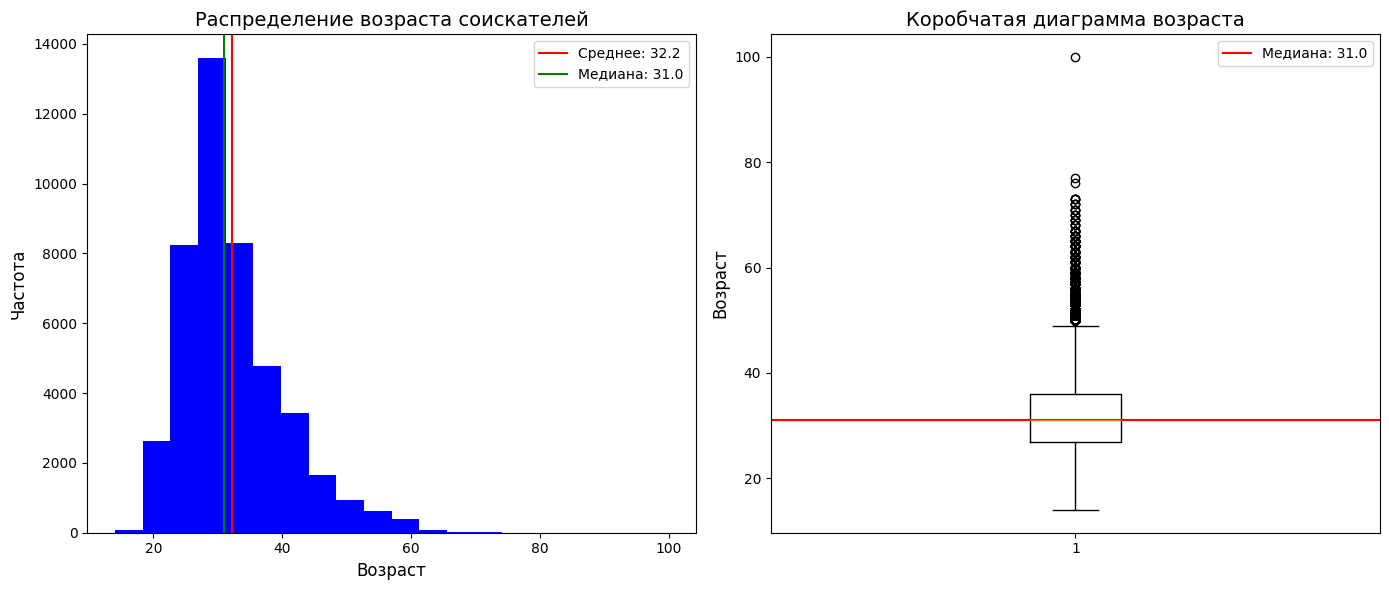

Слишком молодые (менее 18 лет): 21
Пенсионные (женщины 60+, мужчины 65+): 230
Некорректные (0 и отрицательные): 0


In [194]:
data['возраст'] = pd.to_numeric(data['Возраст'], errors='coerce')

age_clean = data['возраст'].dropna()

print(f"Мода: {age_clean.mode().values[0] if len(age_clean.mode()) > 0 else 'нет'}")
print(f"Медиана: {age_clean.median()}")

print(f"Минимум: {age_clean.min()}")
print(f"Максимум: {age_clean.max()}")

print(f"Стандартное отклонение: {age_clean.std():.1f}")

Q1 = age_clean.quantile(0.25)
Q3 = age_clean.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n=== Выбросы (IQR метод) ===")
print(f"Нижняя граница: {lower_bound}")
print(f"Верхняя граница: {upper_bound}")
print(f"Количество выбросов: {((age_clean < lower_bound) | (age_clean > upper_bound)).sum()}")
print(f"Доля выбросов: {((age_clean < lower_bound) | (age_clean > upper_bound)).sum() / len(age_clean) * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(age_clean, bins=20, color='blue')
axes[0].axvline(age_clean.mean(), color='red', label=f"Среднее: {age_clean.mean():.1f}")
axes[0].axvline(age_clean.median(), color='green', label=f"Медиана: {age_clean.median():.1f}")
axes[0].set_xlabel('Возраст', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title('Распределение возраста соискателей', fontsize=14)
axes[0].legend()


box = axes[1].boxplot(age_clean, vert=True)
axes[1].set_ylabel('Возраст', fontsize=12)
axes[1].axhline(age_clean.median(), color='red', label=f"Медиана: {age_clean.median():.1f}")
axes[1].set_title('Коробчатая диаграмма возраста', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Слишком молодые (менее 18 лет): {(age_clean < 18).sum()}")
print(f"Пенсионные (женщины 60+, мужчины 65+): {(age_clean >= 60).sum()}")
print(f"Некорректные (0 и отрицательные): {(age_clean <= 0).sum()}")

# Анализ распределения возраста

1. **Мода** распределения возраста равна **30 годам**.

2. **Предельные значения** составляют от **14 до 49 лет**.

3. **Большинство соискателей** находятся в возрасте от **27 до 36 лет** включительно.

4. **Аномальные значения**:
   - возраст **100 лет**
   - возраст от **65 лет** (превышает пенсионный возраст, установленный законодательством)

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

Мода: 81.0
Пределы: 1 - 24230 мес.
50% соискателей: 57 - 155 мес. (4.8 - 12.9 лет)
Аномалии: 1256 шт. (2.8%)


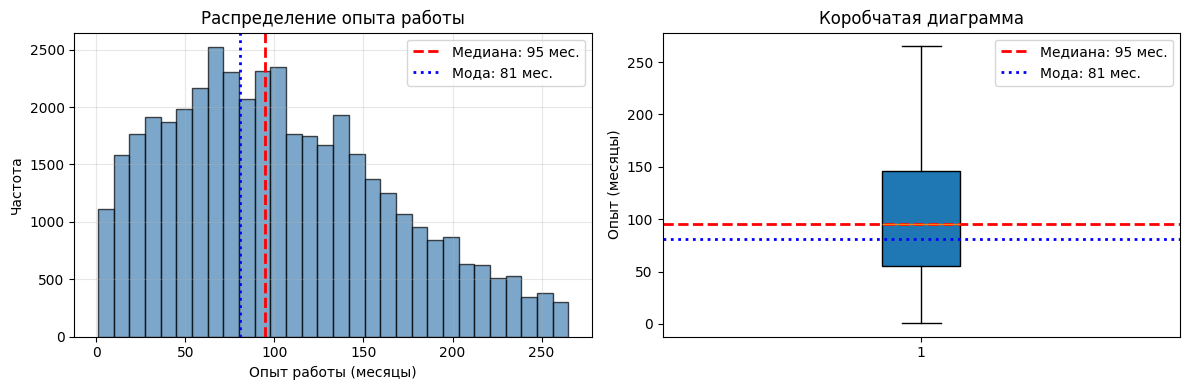

In [195]:
# Подготовка
exp = data['Опыт работы (месяц)'].dropna()

# Ограничим выбросы для наглядности
cap = exp.quantile(0.95)
exp_clean = exp[exp <= cap]

# Статистики
Q1, Q3 = exp.quantile(0.25), exp.quantile(0.75)
IQR = Q3 - Q1
outliers = exp[(exp < Q1 - 1.5*IQR) | (exp > Q3 + 1.5*IQR)]

print(f"Мода: {exp_clean.mode().values[0]}")
print(f"Пределы: {exp.min():.0f} - {exp.max():.0f} мес.")
print(f"50% соискателей: {Q1:.0f} - {Q3:.0f} мес. ({Q1/12:.1f} - {Q3/12:.1f} лет)")
print(f"Аномалии: {len(outliers)} шт. ({len(outliers)/len(exp)*100:.1f}%)")
#print(f"Пенсионный возраст: {np.sum(exp > 540)}")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(exp_clean, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(exp_clean.median(), color='red', linestyle='--', linewidth=2, 
                label=f'Медиана: {exp_clean.median():.0f} мес.')
axes[0].axvline(exp_clean.mode()[0], color='blue', linestyle=':', linewidth=2,
                label=f'Мода: {exp_clean.mode()[0]:.0f} мес.')
axes[0].set_xlabel('Опыт работы (месяцы)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение опыта работы')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].boxplot(exp_clean, vert=True, patch_artist=True)
axes[1].set_ylabel('Опыт (месяцы)')
axes[1].axhline(exp_clean.median(), color='red', linestyle='--', linewidth=2, 
                label=f'Медиана: {exp_clean.median():.0f} мес.')
axes[1].axhline(exp_clean.mode()[0], color='blue', linestyle=':', linewidth=2,
                label=f'Мода: {exp_clean.mode()[0]:.0f} мес.')
axes[1].set_title('Коробчатая диаграмма')
axes[1].legend()



plt.tight_layout()
plt.show()

# Анализ распределения возраста

1. **Мода** распределения опыта равна **81 мес.**.

2. **Предельные значения** составляют от **0 до 24230 мес.**.

3. **Большинство соискателей** находятся в возрасте от **56 до 154 мес.** включительно.

4. **Аномальные значения**:
   - опыт работы **24230 мес.**


**Мода опыта работы согласуется с модой возраста, то есть, данные, скорее всего, достоверны.**

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


Мода: 50000.0
От и до: 1 - 24304876 руб
Выбросы: 2781 (6.2%)
от: 37000 и до: 90000 желаемой зп половины соискателей


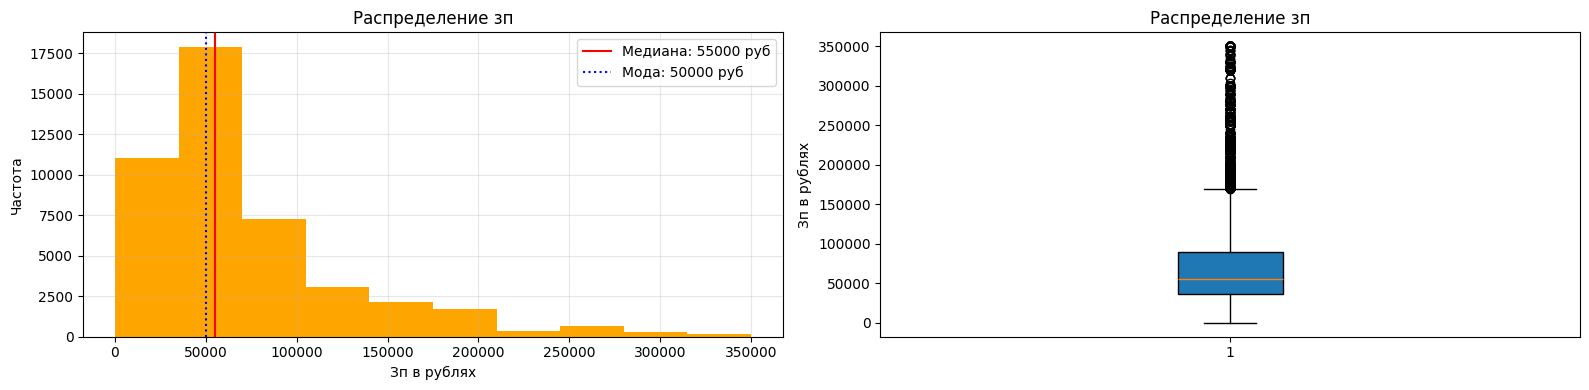

In [196]:
# Константы
SALARY_CAP = 350_000
IQR_MULTIPLIER = 1.5

# Подготовка данных
salary = data['ЗП (руб)']

# Очищенные данные
salary_clean = salary[salary <= SALARY_CAP]

# Статистика по исходным данным
Q1_raw, Q3_raw = salary.quantile(0.25), salary.quantile(0.75)
IQR_raw = Q3_raw - Q1_raw

outliers_raw = salary[
    (salary < Q1_raw - IQR_MULTIPLIER * IQR_raw) |
    (salary > Q3_raw + IQR_MULTIPLIER * IQR_raw)
]

# Вывод статистики
print(f"Мода: {salary_clean.mode().values[0]}")
print(f"От и до: {salary.min():.0f} - {salary.max():.0f} руб")
print(
    f"Выбросы: {len(outliers_raw)} "
    f"({len(outliers_raw) / len(salary) * 100:.1f}%)"
)
print(
    f"от: {salary_clean.quantile(0.25):.0f} "
    f"и до: {salary_clean.quantile(0.75):.0f} "
    f"желаемой зп половины соискателей"
)

# Создание графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Гистограмма
axes[0].hist(salary_clean, bins=10, color='orange')
axes[0].axvline(
    salary_clean.median(),
    color='red',
    linestyle='-',
    label=f'Медиана: {salary_clean.median():.0f} руб'
)
axes[0].axvline(
    salary_clean.mode().values[0],
    color='blue',
    linestyle=':',
    label=f'Мода: {salary_clean.mode().values[0]:.0f} руб'
)
axes[0].set_xlabel('Зп в рублях')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение зп')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(salary_clean, vert=True, patch_artist=True)
axes[1].set_ylabel('Зп в рублях')
axes[1].set_title('Распределение зп')

plt.tight_layout()
plt.show()

# Анализ распределения желаемой зп

1. Мода ожиданий равна **50000** рублей в мес.

2. Предельные значения составляют **от 0 до 242304876** рублей в мес.

3.  Аномальные значения:
   - Уровень зп выше **350 тысяч рублей** назначается для **топ - менеджеров**, они способны найти работу по другим каналам.


#### **Медиана зп расположена на уровне 55 тысяч рублей, а большинство указывают от 37000 и до 90000 желаемой зп**

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

МЕДИАННАЯ ЖЕЛАЕМАЯ ЗАРПЛАТА ПО УРОВНЯМ ОБРАЗОВАНИЯ

высшее                    :     60,000 руб
неоконченное высшее       :     50,000 руб
среднее                   :     40,000 руб
среднее специальное       :     40,000 руб


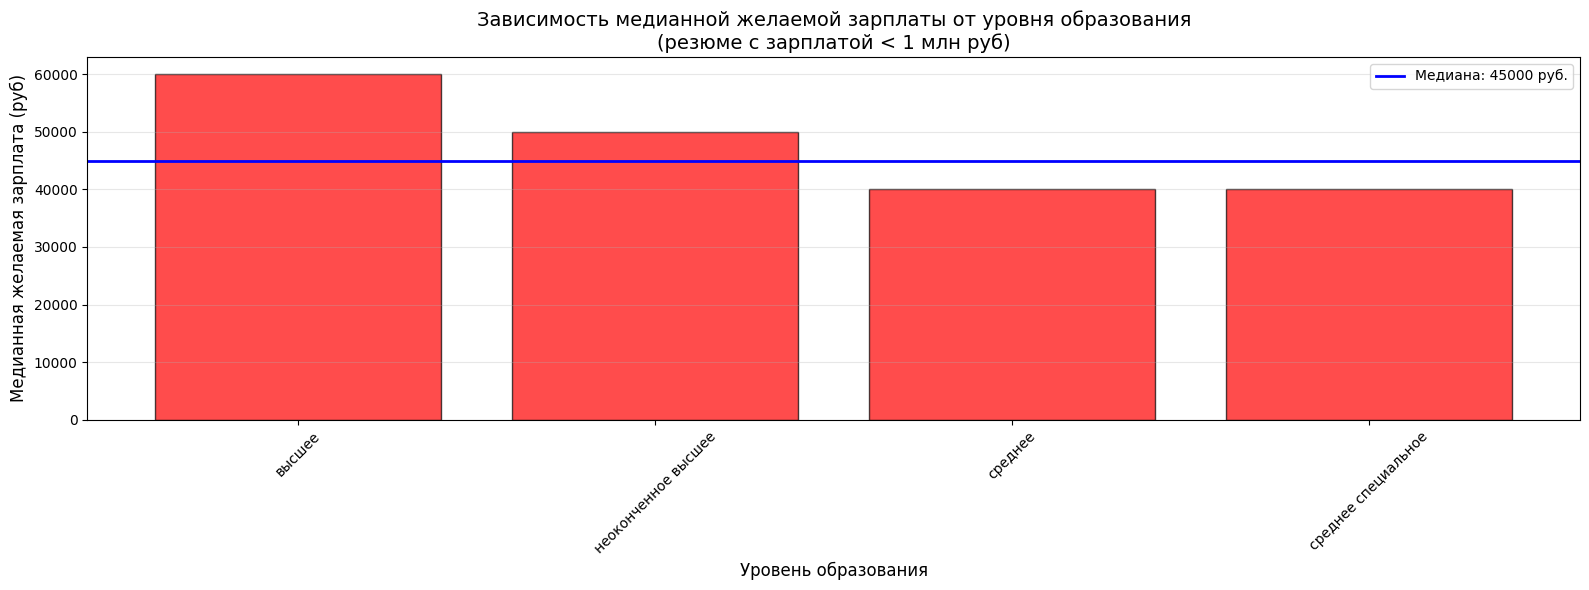

Средний уровень медианной зарплаты: 47,500 руб


In [197]:
SALARY_LIMIT = 1_000_000

# Берём только резюме с зарплатой меньше 1 млн рублей
salary_data = data[data['ЗП (руб)'] < SALARY_LIMIT]

# Удаляем пропуски в образовании и зарплате
salary_data = salary_data.dropna(subset=['Образование', 'ЗП (руб)'])

# Расчёт медианной зарплаты по уровню образования
median_salary_by_edu = (
    salary_data
    .groupby('Образование')['ЗП (руб)']
    .median()
    .sort_values(ascending=False)
)

print("МЕДИАННАЯ ЖЕЛАЕМАЯ ЗАРПЛАТА ПО УРОВНЯМ ОБРАЗОВАНИЯ")
print()
for edu, salary in median_salary_by_edu.items():
    print(f"{edu:25} : {salary:>10,.0f} руб")

# Сортировка по убыванию зарплаты
order = median_salary_by_edu.index.tolist()

# Построение диаграммы
fig, ax = plt.subplots(figsize=(16, 6))

# Столбчатая диаграмма
bars = ax.bar(
    order,
    median_salary_by_edu.values,
    color='red',
    edgecolor='black',
    alpha=0.7
)

# Настройка графика
ax.set_xlabel('Уровень образования', fontsize=12)
ax.set_ylabel('Медианная желаемая зарплата (руб)', fontsize=12)
ax.set_title(
    'Зависимость медианной желаемой зарплаты от уровня образования\n'
    '(резюме с зарплатой < 1 млн руб)',
    fontsize=14
)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45) # Поворот подписей на оси X для лучшей читаемости
ax.axhline(median_salary_by_edu.median(), color='blue', linestyle='-', linewidth=2, 
                label=f'Медиана: {median_salary_by_edu.median():.0f} руб.')
ax.legend()


plt.tight_layout()
plt.show()

# Дополнительная статистика
print(f"Средний уровень медианной зарплаты: {median_salary_by_edu.mean():,.0f} руб")

### Выводы по диаграмме

#### Наибольшая медианная зарплата

* Наибольшая медианная желаемая заработная плата наблюдается у соискателей с высшим образованием (60 тыс. руб). Это объясняется тем, что высшее образование часто является обязательным требованием для высокооплачиваемых должностей.

#### Наименьшая медианная зарплата

* Наименьшая медианная желаемая заработная плата — у соискателей с **средним образованием** (40 тыс. руб). Это ожидаемо, так как без профессионального образования доступны в основном низкоквалифицированные позиции.

##### Важность признака "Образование" для прогнозирования

* Признак "Образование" важен при прогнозировании заработной платы, поскольку:

    1. Разница в медианной зарплате между "Высшим" и "Средним" образованием составляет около 20 тыс.
    2. Наблюдается чёткий тренд: чем выше уровень образования, тем выше ожидаемая зарплата.
    3. Исключение может составлять категория "Не указано", которая показывает промежуточные значения.

#### Однако для точного прогноза необходимы и другие признаки:
* Опыт работы, профессия, регион, размер компании и т.д "Образование" является значимым, но не единственным фактором.

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

МЕДИАННАЯ ЖЕЛАЕМАЯ ЗАРПЛАТА

Москва                    :     85,000 руб
Санкт-Петербург           :     60,000 руб
город миллионник          :     40,000 руб
другие                    :     40,000 руб


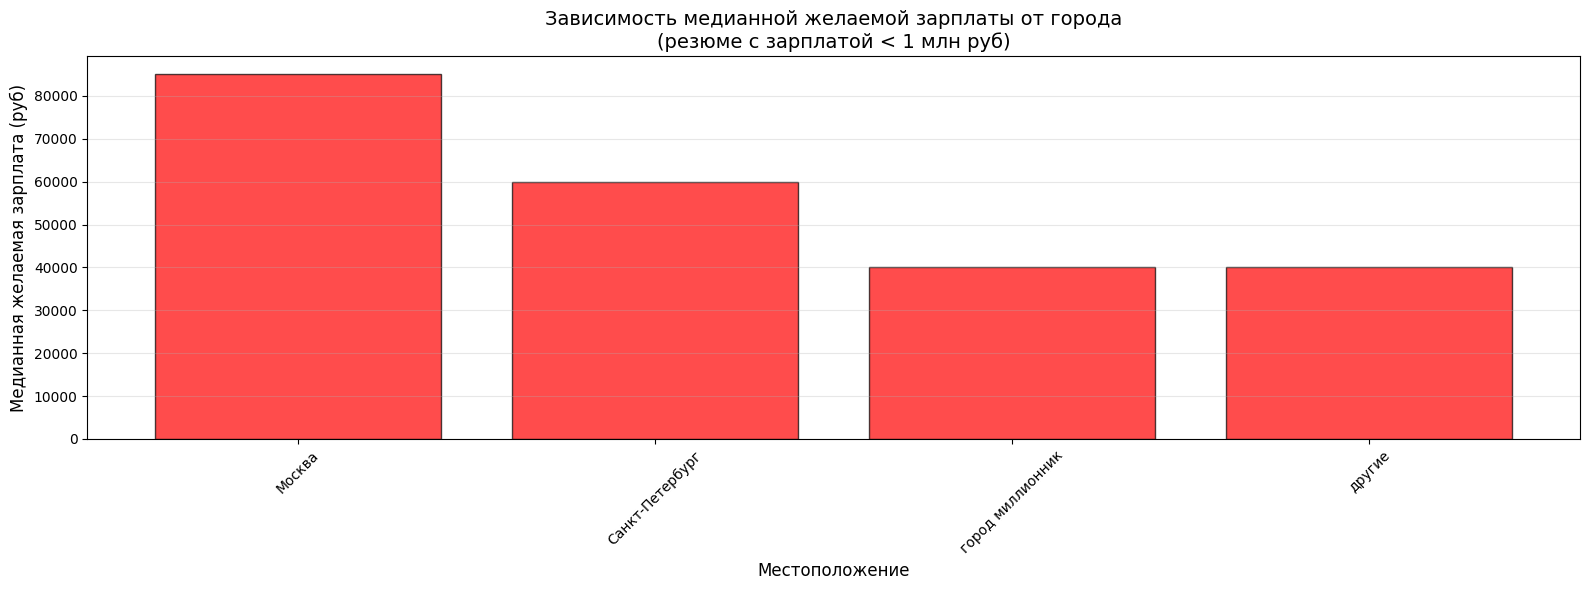

In [198]:
SALARY_LIMIT = 1_000_000

# Берём только резюме с зарплатой меньше 1 млн рублей
salary_data = data[data['ЗП (руб)'] < SALARY_LIMIT]

# Удаляем пропуски
salary_data = salary_data.dropna(subset=['Город', 'ЗП (руб)'])

# Расчёт медианной зарплаты
median_salary_by = (
    salary_data
    .groupby('Город')['ЗП (руб)']
    .median()
    .sort_values(ascending=False)
)

print("МЕДИАННАЯ ЖЕЛАЕМАЯ ЗАРПЛАТА")
print()
for edu, salary in median_salary_by.items():
    print(f"{edu:25} : {salary:>10,.0f} руб")

# Сортировка по убыванию зарплаты
order = median_salary_by.index.tolist()

# Построение диаграммы
fig, ax = plt.subplots(figsize=(16, 6))

# Столбчатая диаграмма
bars = ax.bar(
    order,
    median_salary_by.values,
    color='red',
    edgecolor='black',
    alpha=0.7
)

# Настройка графика
ax.set_xlabel('Местоположение', fontsize=12)
ax.set_ylabel('Медианная желаемая зарплата (руб)', fontsize=12)
ax.set_title(
    'Зависимость медианной желаемой зарплаты от города\n'
    '(резюме с зарплатой < 1 млн руб)',
    fontsize=14
)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45) # Поворот подписей на оси X для лучшей читаемости


plt.tight_layout()
plt.show()


## Выводы:

* Медианный уровень заработной платы в целом по стране одинаковый, кроме двух мегаполисов (Москва и СПБ). При этом в Москве заработная плата выше, чем в Санкт-Петербурге 85 и 60 тыс. руб. соответственно.

* Если сравнить разброс заработных плат в Москве и СПБ, то видно, что Медианный показатель Москвы стоит на уровне третей квантили Санкт-Петербурга, соответственно также совладают уровни первой квантили Москвы и медианного уровня в СПБ.

* В связи с этим признак можно сделать вывод, что "Город" важен для анализа, т.к. он распределяет наши данные на 3 основные категории: Москва, СПБ и остальные.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

In [199]:
bar_trip = data[data['ЗП (руб)']<350_000].groupby(
    by=['Готовность к переезду', 'Готовность к командировкам'], 
    as_index=False
)['ЗП (руб)'].median()

fig = px.bar(
    bar_trip,
    x='Готовность к переезду',
    y='ЗП (руб)',
    color="Готовность к командировкам",
    barmode='group',
    title='Зависимость медианной заработной платы от готовности к переезду или командировкам',
    labels={'ЗП (руб)': 'Медианная зарплата (руб)', 'Переезд': 'Готовность к переезду'},
    text='ЗП (руб)'
)

fig.show()

### Выводы:
 
Из диаграммы видно, что признаки готовности к переезду или к командировкам увеличивают уровень желаемой заработной платы, так "Готовность к командировкам" без учета "готовности к переезду" приводит к увеличению ожидания з/п на 10 тыс.руб., а "готовности к переезду" на 35 тыс.руб.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

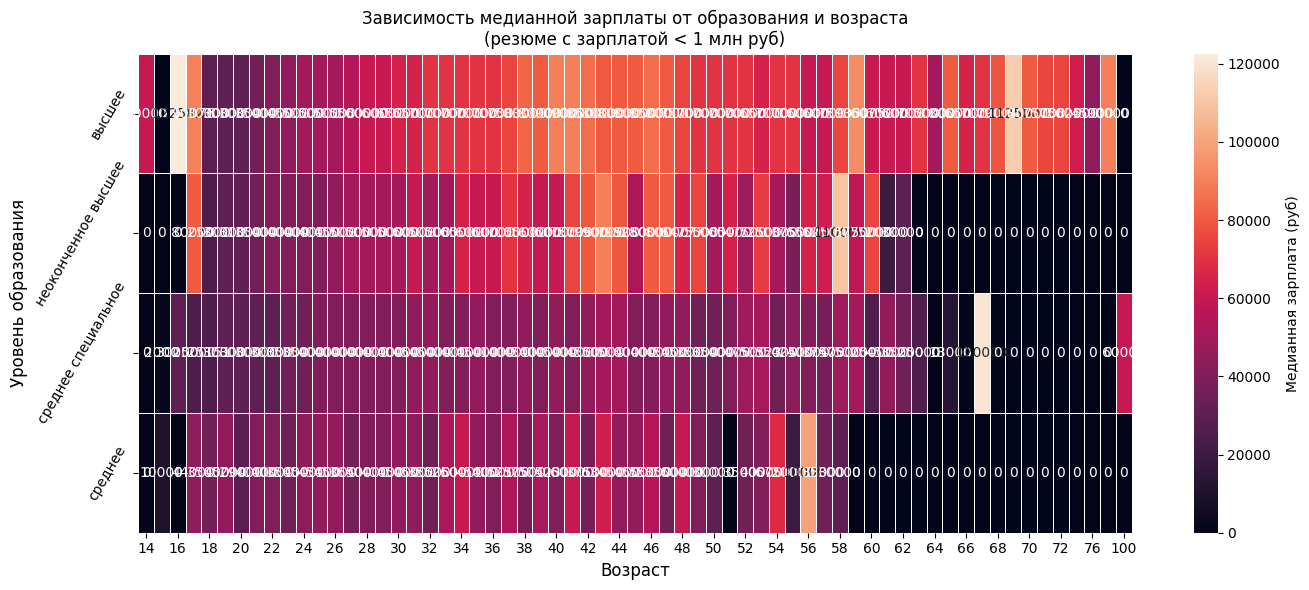

In [200]:
SALARY_LIMIT = 1_000_000

salary_clean = data[data['ЗП (руб)'] < SALARY_LIMIT].dropna(
    subset=['ЗП (руб)', 'Возраст', 'Образование']
)

median_salary = salary_clean.pivot_table(
    values='ЗП (руб)',
    index='Образование',
    columns='Возраст',
    aggfunc='median',
    fill_value=0
)

# Сортировка по возрасту (чтобы столбцы шли по порядку)
median_salary = median_salary.sort_index(axis=1)

# Сортировка образования по убыванию зарплаты (самые высокооплачиваемые сверху)
education_order = median_salary.mean(axis=1).sort_values(ascending=False).index
median_salary = median_salary.loc[education_order]

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    data=median_salary,
    annot=True,
    fmt='.0f',
    square=False,
    linewidths=0.5,          # тонкие линии между клетками
    linecolor='white',       # цвет линий
    cbar_kws={'label': 'Медианная зарплата (руб)'},
    ax=ax
)

ax.set_title(
    'Зависимость медианной зарплаты от образования и возраста\n(резюме с зарплатой < 1 млн руб)'
)
ax.set_xlabel('Возраст', fontsize=12)
ax.set_ylabel('Уровень образования', fontsize=12)

# Поворот подписей оси Y для читаемости
plt.yticks(rotation=60, ha='right')

plt.tight_layout()
plt.show()



### Выводы:
* Из тепловой карты видно, что рост заработной платы с учетом возраста увеличивается в категориях Высшее и неоконченное высшее образование. Из этого можно сделать, что люди, имеющие высшее образование более ценятся с опытом и имеют определенный карьерный рост, по сравнению с соискателями среднего уровня образования. Основной прослеживаемый пик уровня з/п наблюдается у соискателей в возрасте около 40 лет с высшим образованием и 43 лет с неоконченным высшим.

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

In [212]:
# Добавляем столбец с опытом в годах
data['Опыт работы (лет)'] = data['Опыт работы (месяц)'] / 12

# Фильтруем аномальные данные
data_filtered = data[
    (data['Возраст'] >= 18) &
    (data['Возраст'] <= 65) &
    (data['Опыт работы (лет)'] >= 0) &
    (data['Опыт работы (лет)'] <= data['Возраст'] - 18)
]

# Дополнительно убираем экстремальные выбросы по методу межквартильного размаха (IQR) для опыта
Q1 = data_filtered['Опыт работы (лет)'].quantile(0.25)
Q3 = data_filtered['Опыт работы (лет)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_clean = data_filtered[
    (data_filtered['Опыт работы (лет)'] >= lower_bound) &
    (data_filtered['Опыт работы (лет)'] <= upper_bound)
]

# Построение диаграммы рассеяния
fig = px.scatter(
    data_clean,
    x='Возраст',
    y='Опыт работы (лет)',
    labels={
        'Возраст': 'Возраст соискателей (лет)',
        'Опыт работы (лет)': 'Опыт работы (лет)'
    },
    title='Взаимосвязь возраста с опытом работы<br><sup>(без аномальных значений)</sup>',
    width=1000,
    height=500,
    opacity=0.6
)

# Добавляем линию: гипотетический максимум (начало карьеры в 18 лет)
max_x = data_clean['Возраст'].max()
fig.add_shape(
    type='line',
    x0=18,
    y0=0,
    x1=max_x,
    y1=max_x - 18,
    line=dict(color='red', width=2, dash='dash'),
    xref='x',
    yref='y',
    name='Гипотетический максимум: начало карьеры в 18 лет'
)

fig.update_layout(
    xaxis_title='Возраст соискателей (лет)',
    yaxis_title='Опыт работы (лет)',
    font=dict(size=12),
    plot_bgcolor='white',
    xaxis=dict(gridcolor='lightgray', gridwidth=0.5),
    yaxis=dict(gridcolor='lightgray', gridwidth=0.5)
)

fig.show()


# Выводы:

* ### Сильная положительная корреляция

    Наблюдается явная линейная зависимость между возрастом и опытом работы: чем старше соискатель, тем больше у него лет опыта. Точки концентрируются вдоль восходящей линии.
* ### Вариативность внутри возрастных групп

    Молодые (20–30 лет): Разброс небольшой — большинство имеют опыт 0–8 лет, что логично.
    
    Средний возраст (30–50 лет): Разброс максимальный — встречаются как специалисты с непрерывным стажем с 18 лет, так и те, кто начал работать позже или менял карьеру.

    Старшие (50–65 лет): Разброс сужается, многие приближаются к максимально возможному стажу.
* ### Реалистичный разрыв

    Типичный разрыв между возрастом и опытом составляет 15–25 лет — именно столько обычно требуется на детство, юность и обучение перед началом трудовой деятельности.

 **После 42 лет разброс опыта работы уменьшается, а связь «возраст → опыт» становится почти предопределенной. Это объясняется тем, что к этому возрасту большинство соискателей уже имеют непрерывный стаж с 18–22 лет, а альтернативные карьерные траектории (поздний старт, длительные перерывы) встречаются реже или такие кандидаты покидают традиционный рынок труда.**

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


In [202]:
sex_salary = data[data['ЗП (руб)'] < 350_000]

medians = sex_salary.groupby('Пол')['ЗП (руб)'].median()

fig = px.box(
    sex_salary,
    x='Пол',
    y='ЗП (руб)',
    color='Пол',
    title='Распределение ожидаемой заработной платы по полу'
)

# Добавляем линию для мужчин (красная, сплошная)
fig.add_hline(
    y=medians['М'],
    line_dash='solid',
    line_color='blue',
    line_width=2,
    annotation_text=f"Медиана (М): {medians['М']:,.0f} руб",
    annotation_position="top right"
)

# Добавляем линию для женщин (синяя, пунктирная)
fig.add_hline(
    y=medians['Ж'],
    line_dash='dash',
    line_color='red',
    line_width=2,
    annotation_text=f"Медиана (Ж): {medians['Ж']:,.0f} руб",
    annotation_position="bottom right"
)

fig.update_layout(
    title_x=0.5,
    yaxis_title='Зарплата (руб)',
    xaxis_title=''
)

fig.show()

## Выводы:
 Можно заметить пол соискателя влияет на уровень ожидаемой заработной платы. Так женщины ищут работу с уровнем оплаты ниже на 25%, чем мужчины (медианные показатели М:60 тыс.руб., Ж:47 тыс.руб.) Сильная разница у верхних значений, таких как третья квантиль или максимальный показатель. Здесь разница превышает 45%.

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [203]:
duplicates = data[data.duplicated()]
data = data.drop_duplicates()

display(f"Дубликатов: {duplicates.shape[0]}")

'Дубликатов: 161'

2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [218]:
null_data = data.isna().sum()
display(null_data[null_data > 0])

Series([], dtype: int64)

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [219]:
data = data.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])

data['Опыт работы (месяц)'] = data['Опыт работы (месяц)'].fillna(data['Опыт работы (месяц)'].median())

display(f"Среднее значение: {round(data['Опыт работы (месяц)'].mean())}")

'Среднее значение: 108'

4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [221]:
SALARY_HIGH_LIMIT = 1_000_000

SALARY_LOWER_LIMIT = 1_000

outliers = data[(data['ЗП (руб)']>SALARY_HIGH_LIMIT) | (data['ЗП (руб)']<SALARY_LOWER_LIMIT)]
display(f"Выбросов: {outliers.shape[0]}")


'Выбросов: 82'

5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [224]:
outliers_age = data[(data['Опыт работы (месяц)']/12) >= data['Возраст'] ]
data = data.drop(outliers_age.index)
display(f"Выбросов: {outliers_age.shape[0]}")

'Выбросов: 0'

6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

In [ ]:
# ваш код здесь

ваш коммментарий здесь